# Explainable Multimodal Medical Diagnosis - Colab Training Notebook

This notebook is set up to train the Multimodal DenseNet+BERT model on Google Colab using a GPU.

In [1]:
# 1. Check if GPU is enabled
!nvidia-smi

Fri May  1 21:50:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# 2. Clone your GitHub repository
# Note: Replace the URL with your exact repository URL if different.
!git clone https://github.com/toqeer-ahmed/Explainable-Multimodal-Medical-Diagnosis-Using-Chest-X-ray-Images-and-Clinical-Text-.git project_code
%cd project_code

Cloning into 'project_code'...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 20 (delta 1), reused 20 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (20/20), 120.16 KiB | 30.04 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/project_code


In [3]:
# 3. Install required libraries
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 89.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=66bb604f81a45a39401a63a09d1785b977ab8c77bd2bcf42af347b6009b1923e
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


## 4. Mount Google Drive (Data Access)

Since your data is large, it's best to zip your `data/` folder from your local machine and upload it to Google Drive.

1. Locally, zip your `data/` folder into `data.zip`.
2. Upload `data.zip` to your Google Drive.
3. Run the cell below to mount drive and unzip it into the Colab workspace.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip data from your Drive into the project directory
# Change the path below if you placed data.zip in a specific folder inside Drive (e.g., /content/drive/MyDrive/Project/data.zip)
!unzip /content/drive/MyDrive/data.zip -d /content/project_code/

Streaming output truncated to the last 5000 lines.
  inflating: /content/project_code/data/images/CXR503_IM-2121-1001.png  
  inflating: /content/project_code/data/images/CXR503_IM-2121-2001.png  
  inflating: /content/project_code/data/images/CXR504_IM-2122-1001.png  
  inflating: /content/project_code/data/images/CXR504_IM-2122-2001.png  
  inflating: /content/project_code/data/images/CXR505_IM-2123-1001.png  
  inflating: /content/project_code/data/images/CXR505_IM-2123-2001.png  
  inflating: /content/project_code/data/images/CXR506_IM-2124-1001.png  
  inflating: /content/project_code/data/images/CXR506_IM-2124-3003.png  
  inflating: /content/project_code/data/images/CXR507_IM-2125-1001.png  
  inflating: /content/project_code/data/images/CXR507_IM-2125-2001.png  
  inflating: /content/project_code/data/images/CXR508_IM-2125-1001.png  
  inflating: /content/project_code/data/images/CXR508_IM-2125-1002.png  
  inflating: /content/project_code/data/images/CXR509_IM-2125-1001.png  


In [9]:
!git pull
!python -m src.train --batch_size 32 --epochs 10 --lr 2e-5

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 362 bytes | 362.00 KiB/s, done.
From https://github.com/toqeer-ahmed/Explainable-Multimodal-Medical-Diagnosis-Using-Chest-X-ray-Images-and-Clinical-Text-
   7f2aefc..bd2aae8  main       -> origin/main
Updating 7f2aefc..bd2aae8
Fast-forward
 src/data_loader.py | 2 +-
 1 file changed, 1 insertion(+), 1 deletion(-)
Using device: cuda
Loading data...
Number of classes: 747
Initializing Multimodal Fusion Model...
Loading weights: 100% 199/199 [00:00<00:00, 965.50it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias         

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 449 bytes | 449.00 KiB/s, done.
From https://github.com/toqeer-ahmed/Explainable-Multimodal-Medical-Diagnosis-Using-Chest-X-ray-Images-and-Clinical-Text-
   bf5723e..38116ee  main       -> origin/main
Updating bf5723e..38116ee
Fast-forward
 src/model_text.py | 3 ++-
 1 file changed, 2 insertions(+), 1 deletion(-)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please 

Visualizing Explainability for predicted disease: deformity/heart/right


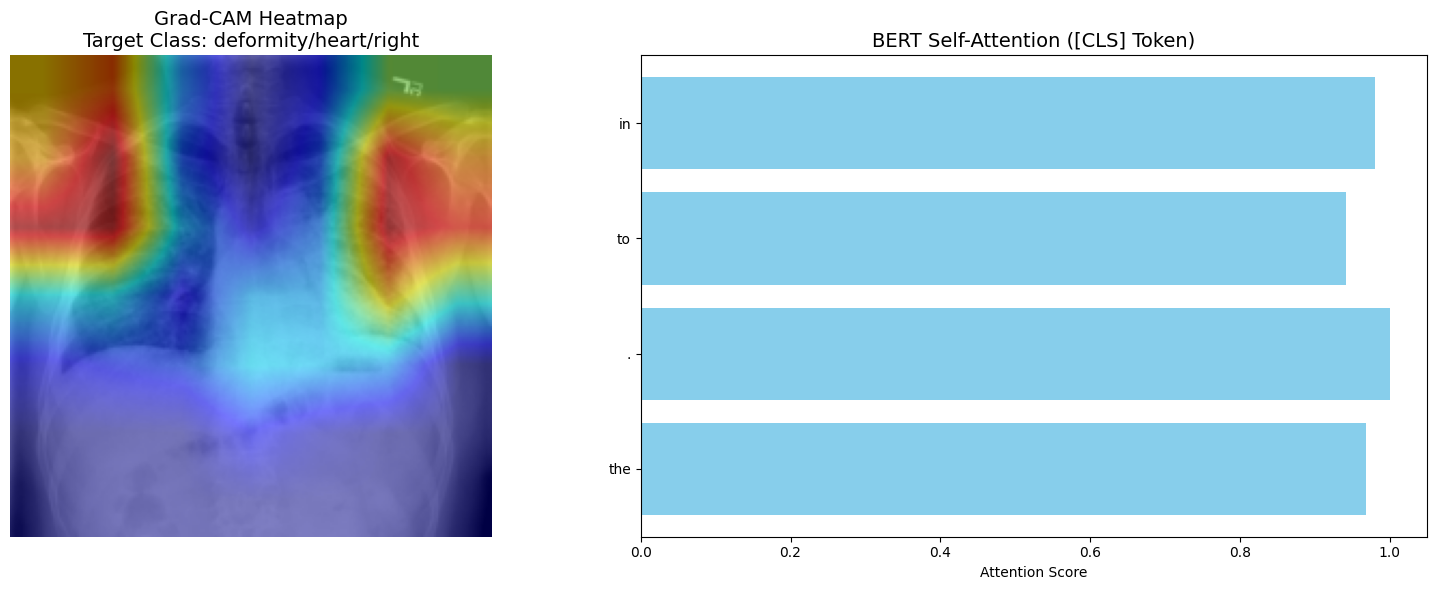

In [15]:
!git pull

import torch
import pandas as pd
import numpy as np

# Force Python to reload the updated model classes
import importlib
import src.model_text
import src.fusion_model
import src.explainability
importlib.reload(src.model_text)
importlib.reload(src.fusion_model)
importlib.reload(src.explainability)

from src.fusion_model import MultimodalFusion
from src.data_loader import get_data_loaders
from src.explainability import generate_gradcam, get_text_attention, visualize_explainability

# 1. Load the best trained model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df_labels = pd.read_csv('data/processed/labels.csv')
num_classes = len(df_labels)

model = MultimodalFusion(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('outputs/models/best_model.pth'))
model.eval()

# 2. Get a sample from our dataloader
train_loader, val_loader, _ = get_data_loaders('data/processed/dataset.csv', batch_size=1)
sample = next(iter(val_loader))

# Extract the tokenizer from the dataset object
tokenizer = val_loader.dataset.dataset.tokenizer

images = sample['image']
input_ids = sample['input_ids']
attention_mask = sample['attention_mask']

# Prepare image for visualization (un-normalize)
mean = np.array([0.485, 0.456, 0.406]).reshape((3, 1, 1))
std = np.array([0.229, 0.224, 0.225]).reshape((3, 1, 1))
img_np = images[0].cpu().numpy()
img_unnorm = (img_np * std) + mean
img_unnorm = np.transpose(img_unnorm, (1, 2, 0))
img_unnorm = np.clip(img_unnorm, 0, 1)

# 3. Generate Explainability
# Run Grad-CAM on the Image
vis_image, target_idx = generate_gradcam(
    model=model,
    image_tensor=images,
    input_ids=input_ids,
    attention_mask=attention_mask,
    original_image=img_unnorm,
    device=device
)

# Extract Self-Attention from BERT
tokens, att_scores = get_text_attention(
    model=model,
    input_ids=input_ids,
    attention_mask=attention_mask,
    tokenizer=tokenizer,
    device=device
)

# 4. Plot the results!
class_name = df_labels.iloc[target_idx]['class_name']
print(f"Visualizing Explainability for predicted disease: {class_name}")
visualize_explainability(vis_image, tokens, att_scores, class_name)


In [16]:
!git pull
!python -m src.evaluate


remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.87 KiB | 1.87 MiB/s, done.
From https://github.com/toqeer-ahmed/Explainable-Multimodal-Medical-Diagnosis-Using-Chest-X-ray-Images-and-Clinical-Text-
   38116ee..22a4bd7  main       -> origin/main
Updating 38116ee..22a4bd7
Fast-forward
 src/evaluate.py | 113 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 113 insertions(+)
 create mode 100644 src/evaluate.py
Loading weights: 100% 199/199 [00:00<00:00, 1051.99it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPEC